# Pandas 기초 실습: 판매 데이터 100행

`sample_sales_100.csv`로 표 데이터를 읽고, 원하는 행을 찾고, 판매 금액을 집계합니다.
파이썬 변수, 리스트, 조건식을 배운 학습자를 위한 예제입니다. 데이터는 실습용 가상 데이터입니다.

## 실행 방법

- **Google Colab:** 이 노트북을 열고 위에서부터 셀을 실행합니다. 파일 선택 창이 나오면 `sample_sales_100.csv`를 업로드합니다.
- **Jupyter / VS Code:** 노트북과 CSV를 같은 폴더에 두고 실행합니다. Python 환경에 `pandas`, `matplotlib`이 필요합니다.
- 실행 단축키는 **Shift + Enter**입니다. 이전 셀의 변수를 사용하므로 처음에는 순서대로 실행하세요.
- 저장된 출력은 예시입니다. 직접 실행하면 현재 실행 결과로 바뀝니다.

## 데이터 구조

한 행은 한 품목의 판매 내역입니다. **100행은 판매 내역 100건이며, 서로 다른 품목 100개를 뜻하지 않습니다.**

| 열 | 의미 | 예시 |
|---|---|---|
| 번호 | 판매 내역 식별 번호 | 1 |
| 날짜 | 판매일 | 2026-09-01 |
| 품목명 | 판매한 상품 | 아메리카노 |
| 분류 | 상품 분류 | 음료 |
| 단가 | 상품 1개의 가격, 원 | 2500 |
| 수량 | 판매 개수 | 14 |
| 금액 | 단가 × 수량, 원 | 35000 |


## 1. 라이브러리와 CSV 불러오기

`import pandas as pd`는 Pandas를 불러오고 `pd`라는 짧은 이름으로 사용한다는 뜻입니다.
`DataFrame`은 행과 열로 구성된 표입니다. 여기서는 `df`라는 변수에 표를 저장합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("sample_sales_100.csv")

if not csv_path.exists():
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError("sample_sales_100.csv를 노트북과 같은 폴더에 두세요.")
    else:
        uploaded = files.upload()
        if csv_path.name not in uploaded:
            raise FileNotFoundError("sample_sales_100.csv를 선택해 업로드하세요.")

# utf-8-sig는 파일 맨 앞의 BOM도 처리합니다.
df = pd.read_csv(csv_path, encoding="utf-8-sig")
display(df.head())

,번호,날짜,품목명,분류,단가,수량,금액
0,1,2026-09-01,아메리카노,음료,2500,14,35000
1,2,2026-09-01,샌드위치,식품,4500,8,36000
2,3,2026-09-01,연필,문구,500,10,5000
3,4,2026-09-01,파일철,문구,3000,20,60000
4,5,2026-09-02,컵라면,식품,1800,18,32400


## 2. 데이터 살펴보기

`head()`는 앞 5행, `tail()`은 뒤 5행을 보여 줍니다.
`shape`는 `(행 수, 열 수)`, `columns`는 열 이름 목록입니다.
왼쪽에 표시되는 **인덱스**는 Pandas가 붙인 행 라벨이며, CSV의 `번호` 열과 별개입니다.


In [2]:
display(df.head(3))
display(df.tail(3))
print("행 수와 열 수:", df.shape)
print("열 이름:", df.columns.tolist())

행 수와 열 수: (100, 7)
열 이름: ['번호', '날짜', '품목명', '분류', '단가', '수량', '금액']


,번호,날짜,품목명,분류,단가,수량,금액
0,1,2026-09-01,아메리카노,음료,2500,14,35000
1,2,2026-09-01,샌드위치,식품,4500,8,36000
2,3,2026-09-01,연필,문구,500,10,5000


,번호,날짜,품목명,분류,단가,수량,금액
97,98,2026-09-30,샌드위치,식품,4500,4,18000
98,99,2026-09-30,USB 케이블,전자기기,5000,14,70000
99,100,2026-09-30,마우스,전자기기,15000,12,180000


`info()`로 자료형과 비어 있지 않은 값의 개수를 확인합니다.
`describe()`는 숫자 열의 개수, 평균, 최솟값, 최댓값 등을 요약합니다.
처음에는 날짜가 문자열로 읽힙니다. 뒤에서 날짜 자료형으로 변환합니다.


In [3]:
df.info()
display(df[["단가", "수량", "금액"]].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   번호      100 non-null    int64 
 1   날짜      100 non-null    object
 2   품목명     100 non-null    object
 3   분류      100 non-null    object
 4   단가      100 non-null    int64 
 5   수량      100 non-null    int64 
 6   금액      100 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 5.6+ KB


,단가,수량,금액
count,100.000000,100.000000,100.000000
mean,3520.000000,11.280000,41610.000000
std,3655.879449,6.087045,57182.913143
min,500.000000,2.000000,1000.000000
25%,1800.000000,6.000000,10600.000000
50%,2500.000000,12.000000,25100.000000
75%,4500.000000,16.000000,44000.000000
max,15000.000000,20.000000,300000.000000


## 3. 원하는 열 선택하기

`df["단가"]`는 한 열을 선택하여 `Series`를 반환합니다.
`df[["품목명", "단가"]]`처럼 열 이름을 리스트로 전달하면 `DataFrame`을 반환합니다.


In [4]:
display(df["단가"].head())
display(df[["품목명", "단가", "수량", "금액"]].head())

0    2500
1    4500
2     500
3    3000
4    1800
Name: 단가, dtype: int64

,품목명,단가,수량,금액
0,아메리카노,2500,14,35000
1,샌드위치,4500,8,36000
2,연필,500,10,5000
3,파일철,3000,20,60000
4,컵라면,1800,18,32400


## 4. 조건에 맞는 행 찾기

조건식을 작성하면 각 행에 대해 `True` 또는 `False`가 만들어집니다.
이를 `df[조건]`에 넣으면 `True`인 행만 남습니다.


In [5]:
condition = df["단가"] >= 5000
display(condition.head())
expensive = df[condition]
display(expensive.head(10))
print("단가가 5,000원 이상인 판매 내역:", len(expensive), "건")

단가가 5,000원 이상인 판매 내역: 17 건


0    False
1    False
2    False
3    False
4    False
Name: 단가, dtype: bool

,번호,날짜,품목명,분류,단가,수량,금액
6,7,2026-09-02,USB 케이블,전자기기,5000,14,70000
13,14,2026-09-04,마우스,전자기기,15000,20,300000
16,17,2026-09-05,USB 케이블,전자기기,5000,18,90000
34,35,2026-09-11,USB 케이블,전자기기,5000,18,90000
36,37,2026-09-11,USB 케이블,전자기기,5000,2,10000
37,38,2026-09-12,마우스,전자기기,15000,4,60000
40,41,2026-09-13,USB 케이블,전자기기,5000,10,50000
51,52,2026-09-16,마우스,전자기기,15000,16,240000
53,54,2026-09-16,마우스,전자기기,15000,8,120000
67,68,2026-09-21,마우스,전자기기,15000,20,300000


In [6]:
# 문자열도 조건으로 비교할 수 있습니다.
drinks = df[df["분류"] == "음료"]
display(drinks.head())

,번호,날짜,품목명,분류,단가,수량,금액
0,1,2026-09-01,아메리카노,음료,2500,14,35000
9,10,2026-09-03,오렌지주스,음료,2200,20,44000
10,11,2026-09-04,아메리카노,음료,2500,14,35000
11,12,2026-09-04,오렌지주스,음료,2200,16,35200
14,15,2026-09-05,아메리카노,음료,2500,10,25000


조건을 여러 개 결합할 때는 각각 괄호로 감쌉니다.

- `&`: 두 조건을 모두 만족
- `|`: 두 조건 중 하나 이상 만족

Pandas 열 단위 조건에서는 파이썬의 `and`, `or` 대신 `&`, `|`를 사용합니다.


In [7]:
# 음료이면서 수량이 10개 이상인 판매 내역
selected = df[(df["분류"] == "음료") & (df["수량"] >= 10)]
display(selected[["날짜", "품목명", "수량", "금액"]].head(10))

,날짜,품목명,수량,금액
0,2026-09-01,아메리카노,14,35000
9,2026-09-03,오렌지주스,20,44000
10,2026-09-04,아메리카노,14,35000
11,2026-09-04,오렌지주스,16,35200
14,2026-09-05,아메리카노,10,25000
27,2026-09-09,오렌지주스,16,35200
28,2026-09-09,아메리카노,14,35000
64,2026-09-20,아메리카노,18,45000
71,2026-09-22,오렌지주스,20,44000
78,2026-09-24,아메리카노,14,35000


In [8]:
# 문구 또는 전자기기인 판매 내역
selected = df[(df["분류"] == "문구") | (df["분류"] == "전자기기")]
display(selected.head())

,번호,날짜,품목명,분류,단가,수량,금액
2,3,2026-09-01,연필,문구,500,10,5000
3,4,2026-09-01,파일철,문구,3000,20,60000
5,6,2026-09-02,볼펜,문구,1000,12,12000
6,7,2026-09-02,USB 케이블,전자기기,5000,14,70000
7,8,2026-09-03,파일철,문구,3000,16,48000


### 조건과 열을 함께 선택하기: `loc`

`df.loc[행 조건, 열 이름 리스트]`로 원하는 행과 열을 한 번에 선택할 수 있습니다.


In [9]:
display(df.loc[df["금액"] >= 50000, ["품목명", "단가", "수량", "금액"]].head(10))

,품목명,단가,수량,금액
3,파일철,3000,20,60000
6,USB 케이블,5000,14,70000
13,마우스,15000,20,300000
16,USB 케이블,5000,18,90000
25,파일철,3000,20,60000
31,파일철,3000,20,60000
34,USB 케이블,5000,18,90000
37,마우스,15000,4,60000
40,USB 케이블,5000,10,50000
41,샌드위치,4500,16,72000


## 5. 정렬하고 상위 판매 내역 찾기

`sort_values()`는 지정한 열로 정렬합니다. `ascending=False`는 큰 값부터 정렬합니다.
여기서 상위 5개는 **개별 판매 내역 5건**입니다. 품목별 누적 판매금액 순위는 뒤에서 구합니다.


In [10]:
top_transactions = df.sort_values("금액", ascending=False).head(5)
display(top_transactions[["번호", "품목명", "수량", "금액"]])

,번호,품목명,수량,금액
13,14,마우스,20,300000
67,68,마우스,20,300000
51,52,마우스,16,240000
81,82,마우스,16,240000
77,78,마우스,12,180000


## 6. 새 열 만들기와 금액 확인

열 전체에 곱셈을 적용할 수 있어 `for` 반복문 없이 각 행의 금액을 계산합니다.
`copy()`로 실습용 복사본을 만든 뒤 새 열을 추가합니다.


In [11]:
work = df.copy()
work["계산금액"] = work["단가"] * work["수량"]
work["금액일치"] = work["금액"] == work["계산금액"]
display(work[["품목명", "단가", "수량", "금액", "계산금액", "금액일치"]].head())
print("모든 행의 금액이 일치하는가?", work["금액일치"].all())

모든 행의 금액이 일치하는가? True


,품목명,단가,수량,금액,계산금액,금액일치
0,아메리카노,2500,14,35000,35000,True
1,샌드위치,4500,8,36000,36000,True
2,연필,500,10,5000,5000,True
3,파일철,3000,20,60000,60000,True
4,컵라면,1800,18,32400,32400,True


## 7. 합계와 평균 구하기

`sum()`은 합계, `mean()`은 평균, `max()`는 최댓값을 구합니다.
평균 판매금액은 **판매 내역 한 건당 평균 금액**입니다.
평균 단가는 행별 단가의 단순 평균입니다. 실제 판매된 상품 1개당 평균 금액은 총금액 ÷ 총수량으로 계산합니다.


In [12]:
total_amount = df["금액"].sum()
total_quantity = df["수량"].sum()

print(f"전체 판매금액: {total_amount:,.0f}원")
print(f"전체 판매수량: {total_quantity:,.0f}개")
print(f"판매 내역 한 건당 평균 금액: {df['금액'].mean():,.2f}원")
print(f"가장 큰 개별 판매금액: {df['금액'].max():,.0f}원")
print(f"판매된 상품 1개당 평균 금액: {total_amount / total_quantity:,.2f}원")

전체 판매금액: 4,161,000원
전체 판매수량: 1,128개
판매 내역 한 건당 평균 금액: 41,610.00원
가장 큰 개별 판매금액: 300,000원
판매된 상품 1개당 평균 금액: 3,688.83원


### 분류별 판매 내역 건수

`value_counts()`는 값이 몇 번 나왔는지 셉니다. 아래 결과는 판매 내역의 **건수**이며, 수량의 합이 아닙니다.


In [13]:
display(df["분류"].value_counts())
print("서로 다른 품목 수:", df["품목명"].nunique())

서로 다른 품목 수: 10


분류
문구      34
식품      29
음료      20
전자기기    17
Name: count, dtype: int64

## 8. 분류별·품목별로 묶어서 집계하기

`groupby("분류")`로 같은 분류끼리 묶고, `sum()`으로 각 그룹의 금액을 더합니다.


In [14]:
category_sales = df.groupby("분류")["금액"].sum().sort_values(ascending=False)
display(category_sales)

분류
전자기기    2050000
식품       942000
문구       616000
음료       553000
Name: 금액, dtype: int64

수량과 금액을 함께 합산할 수도 있습니다.
`reset_index()`는 그룹 이름을 일반 열로 바꿉니다.


In [15]:
category_summary = df.groupby("분류")[["수량", "금액"]].sum().reset_index()
category_summary = category_summary.sort_values("금액", ascending=False)
display(category_summary)

,분류,수량,금액
3,전자기기,194,2050000
1,식품,320,942000
0,문구,376,616000
2,음료,238,553000


In [16]:
# 품목별 누적 판매금액 상위 5개
product_sales = df.groupby("품목명")["금액"].sum().sort_values(ascending=False)
display(product_sales.head(5))

품목명
마우스        1620000
샌드위치        576000
파일철         456000
USB 케이블     430000
오렌지주스       308000
Name: 금액, dtype: int64

## 9. 날짜 변환과 일별 집계

`pd.to_datetime()`으로 날짜 문자열을 날짜 자료형으로 변환합니다.
변환하면 날짜 비교와 기간별 집계를 더 편하게 할 수 있습니다.


In [17]:
dated = df.copy()
dated["날짜"] = pd.to_datetime(dated["날짜"], format="%Y-%m-%d")
print("변환 후 날짜 자료형:", dated["날짜"].dtype)

daily_sales = dated.groupby("날짜")["금액"].sum().sort_index()
display(daily_sales.head())

변환 후 날짜 자료형: datetime64[ns]


날짜
2026-09-01    136000
2026-09-02    114400
2026-09-03    120000
2026-09-04    382200
2026-09-05    127000
Name: 금액, dtype: int64

In [18]:
# 9월 1일부터 9월 7일까지의 판매 내역
first_week = dated[(dated["날짜"] >= "2026-09-01") & (dated["날짜"] < "2026-09-08")]
print("첫 7일 판매 내역:", len(first_week), "건")
print(f"첫 7일 판매금액: {first_week['금액'].sum():,.0f}원")

첫 7일 판매 내역: 24 건
첫 7일 판매금액: 1,046,600원


## 10. 간단한 그래프 그리기

Pandas의 `plot()`으로 집계 결과를 시각화합니다.
그래프에는 영어 분류명을 사용해 한국어 폰트 설치 없이 실행할 수 있게 했습니다. 원본 표는 한국어를 유지합니다.


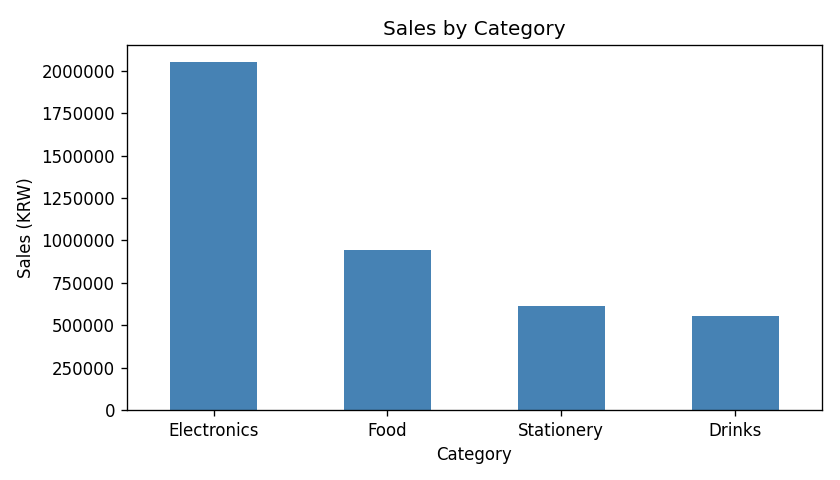

In [19]:
category_labels = {"문구": "Stationery", "음료": "Drinks", "식품": "Food", "전자기기": "Electronics"}
plot_sales = category_sales.rename(index=category_labels)

ax = plot_sales.plot(kind="bar", figsize=(7, 4), color="steelblue", rot=0)
ax.set_title("Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Sales (KRW)")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

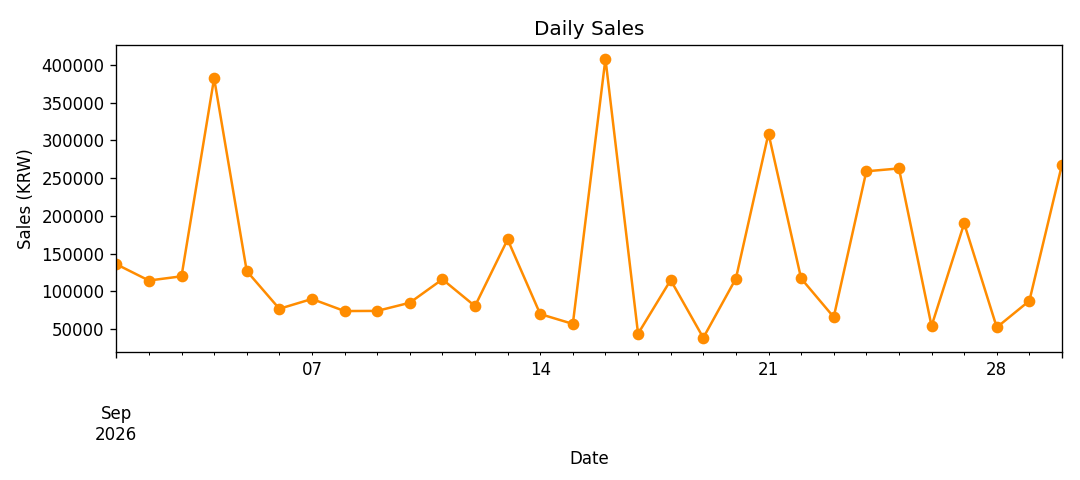

In [20]:
ax = daily_sales.plot(kind="line", figsize=(9, 4), marker="o", color="darkorange")
ax.set_title("Daily Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Sales (KRW)")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

## 11. 결측값과 중복 확인하기

`isna().sum()`은 열별 결측값 수를 확인합니다.
`duplicated().sum()`은 모든 열이 동일한 중복 행 수를 확인합니다.
같은 품목이 여러 번 팔린 것은 정상적인 데이터이므로 품목명이 반복된다는 이유로 삭제하면 안 됩니다.
이 샘플에는 결측값이 없습니다.


In [21]:
display(df.isna().sum())
print("전체 열이 동일한 중복 행 수:", df.duplicated().sum())
print("번호가 중복된 행 수:", df["번호"].duplicated().sum())

전체 열이 동일한 중복 행 수: 0
번호가 중복된 행 수: 0


번호     0
날짜     0
품목명    0
분류     0
단가     0
수량     0
금액     0
dtype: int64

## 12. 집계 결과를 새 CSV로 저장하기

`index=False`는 Pandas 인덱스를 별도 열로 저장하지 않게 합니다.
`encoding="utf-8-sig"`는 엑셀에서 한글을 열기 편한 방식입니다.
아래 셀은 `category_summary.csv`를 새로 저장합니다.


In [22]:
category_summary.to_csv("category_summary.csv", index=False, encoding="utf-8-sig")
print("category_summary.csv 저장 완료")
display(pd.read_csv("category_summary.csv", encoding="utf-8-sig"))

category_summary.csv 저장 완료


,분류,수량,금액
0,전자기기,194,2050000
1,식품,320,942000
2,문구,376,616000
3,음료,238,553000


**Colab에서 결과 다운로드:** 필요할 때 새 코드 셀에 다음 코드를 입력합니다.

```python
from google.colab import files
files.download("category_summary.csv")
```

로컬 환경에서는 현재 작업 폴더에서 파일을 찾을 수 있습니다.


## 연습문제

아래 셀에 코드를 작성하세요. 정답 예시는 노트북 마지막에 있습니다.

1. 단가가 **3,000원 이하**인 판매 내역의 품목명, 단가, 수량을 출력하세요.
2. **전자기기** 분류의 총 판매수량과 총 판매금액을 구하세요.
3. 판매수량이 **15개 이상**인 내역을 금액 내림차순으로 정렬하세요.
4. 품목별 누적 판매수량을 구하고, 가장 많이 팔린 품목 상위 3개를 출력하세요.
5. 분류별 총 판매금액과 전체 판매금액에서 차지하는 비중(%)을 구하세요.


In [23]:
# 연습문제 1: 여기에 코드를 작성하세요.


In [24]:
# 연습문제 2: 여기에 코드를 작성하세요.


In [25]:
# 연습문제 3: 여기에 코드를 작성하세요.


In [26]:
# 연습문제 4: 여기에 코드를 작성하세요.


In [27]:
# 연습문제 5: 여기에 코드를 작성하세요.


## 연습문제 정답 예시

직접 풀어본 뒤 아래 코드를 비교하세요. 같은 결과를 내는 다른 코드도 가능합니다.


In [28]:
# 1. 단가 3,000원 이하
display(df.loc[df["단가"] <= 3000, ["품목명", "단가", "수량"]])

,품목명,단가,수량
0,아메리카노,2500,14
2,연필,500,10
3,파일철,3000,20
4,컵라면,1800,18
5,볼펜,1000,12
7,파일철,3000,16
8,쿠키,2000,14
9,오렌지주스,2200,20
10,아메리카노,2500,14
11,오렌지주스,2200,16


In [29]:
# 2. 전자기기 총수량과 총금액
electronics = df[df["분류"] == "전자기기"]
print("총 판매수량:", electronics["수량"].sum(), "개")
print(f"총 판매금액: {electronics['금액'].sum():,.0f}원")

총 판매수량: 194 개
총 판매금액: 2,050,000원


In [30]:
# 3. 수량 15개 이상, 금액 내림차순
display(df[df["수량"] >= 15].sort_values("금액", ascending=False))

,번호,날짜,품목명,분류,단가,수량,금액
13,14,2026-09-04,마우스,전자기기,15000,20,300000
67,68,2026-09-21,마우스,전자기기,15000,20,300000
51,52,2026-09-16,마우스,전자기기,15000,16,240000
81,82,2026-09-25,마우스,전자기기,15000,16,240000
89,90,2026-09-27,샌드위치,식품,4500,20,90000
57,58,2026-09-18,샌드위치,식품,4500,20,90000
16,17,2026-09-05,USB 케이블,전자기기,5000,18,90000
34,35,2026-09-11,USB 케이블,전자기기,5000,18,90000
87,88,2026-09-27,샌드위치,식품,4500,20,90000
41,42,2026-09-13,샌드위치,식품,4500,16,72000


In [31]:
# 4. 품목별 판매수량 상위 3개
display(df.groupby("품목명")["수량"].sum().sort_values(ascending=False).head(3))

품목명
파일철      152
오렌지주스    140
샌드위치     128
Name: 수량, dtype: int64

In [32]:
# 5. 분류별 판매금액 비중
share = df.groupby("분류")[["금액"]].sum().reset_index()
share["비중(%)"] = share["금액"] / df["금액"].sum() * 100
share = share.sort_values("금액", ascending=False)
display(share.round({"비중(%)": 2}))

,분류,금액,비중(%)
3,전자기기,2050000,49.27
1,식품,942000,22.64
0,문구,616000,14.80
2,음료,553000,13.29


## 자주 쓰는 표현

| 작업 | 코드 |
|---|---|
| CSV 읽기 | `pd.read_csv("sample_sales_100.csv", encoding="utf-8-sig")` |
| 앞 5행 | `df.head()` |
| 행·열 개수 | `df.shape` |
| 여러 열 선택 | `df[["품목명", "금액"]]` |
| 조건 검색 | `df[df["수량"] >= 10]` |
| 내림차순 정렬 | `df.sort_values("금액", ascending=False)` |
| 새 열 계산 | `df["계산금액"] = df["단가"] * df["수량"]` |
| 전체 합계 | `df["금액"].sum()` |
| 그룹별 합계 | `df.groupby("분류")["금액"].sum()` |
| 날짜 변환 | `pd.to_datetime(df["날짜"])` |
| CSV 저장 | `df.to_csv("result.csv", index=False, encoding="utf-8-sig")` |
